In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


In [8]:
# XOR dataset
data = np.array([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], dtype=np.float32)

inputs = torch.tensor(data[:, :2])
outputs = torch.tensor(data[:, 2:], dtype=torch.float32)

In [9]:
# Define model
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = XORNet()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1.0, momentum=0.0)

In [10]:
# Training loop
losses = []
accuracies = []
for epoch in range(1000):
    optimizer.zero_grad()
    outputs_pred = model(inputs)
    loss = criterion(outputs_pred, outputs)
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    predictions = (outputs_pred > 0.5).float()
    acc = (predictions == outputs).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Accuracy: {acc:.4f}")

Epoch    0 | Loss: 0.2501 | Accuracy: 0.5000
Epoch  100 | Loss: 0.2495 | Accuracy: 0.5000
Epoch  200 | Loss: 0.2491 | Accuracy: 0.5000
Epoch  300 | Loss: 0.2481 | Accuracy: 0.5000
Epoch  400 | Loss: 0.2453 | Accuracy: 0.5000
Epoch  500 | Loss: 0.2362 | Accuracy: 0.7500
Epoch  600 | Loss: 0.2091 | Accuracy: 0.7500
Epoch  700 | Loss: 0.1545 | Accuracy: 1.0000
Epoch  800 | Loss: 0.0858 | Accuracy: 1.0000
Epoch  900 | Loss: 0.0437 | Accuracy: 1.0000


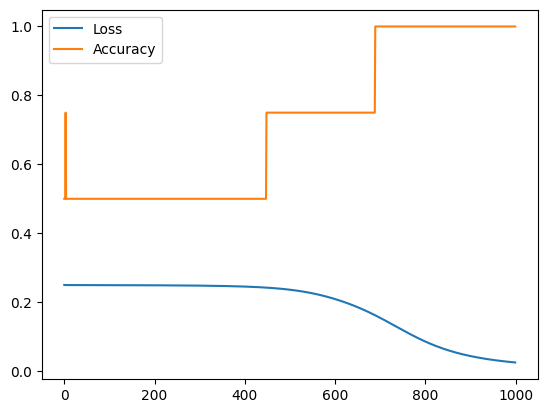

In [11]:
# Plot
plt.plot(losses, label="Loss")
plt.plot(accuracies, label="Accuracy")
plt.legend()
plt.show()

In [12]:
# Evaluation
model.eval()
with torch.no_grad():
    predictions = model(inputs)
    loss = criterion(predictions, outputs)
    acc = ((predictions > 0.5).float() == outputs).float().mean().item()
    print(f"\nFinal evaluation -> Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

    for x, t, y in zip(inputs, outputs, predictions):
        print(x.numpy(), '->', t.item(), '=>', y.item())


Final evaluation -> Loss: 0.0250, Accuracy: 1.0000
[0. 0.] -> 0.0 => 0.12203110009431839
[0. 1.] -> 1.0 => 0.8298934102058411
[1. 0.] -> 1.0 => 0.8447877168655396
[1. 1.] -> 0.0 => 0.17888478934764862
